## Eksik Veri Giderme (Missing Value Problem)

In [ ]:
#gerekli kütüphanelerin yüklenmesi
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno #eksik veri görselleştirme kütüphanesi

In [ ]:
#veriyi yükle
df = pd.read_csv("housing.csv")
print(df.head())

FileNotFoundError: [Errno 2] No such file or directory: 'housing.csv'

In [ ]:
df.columns.to_list()

['CRIM',
 'ZN',
 'INDUS',
 'CHAS',
 'NOX',
 'RM',
 'AGE',
 'DIS',
 'RAD',
 'TAX',
 'PTRATIO',
 'B',
 'LSTAT',
 'MEDV']

In [ ]:
#veri setinin genel özetini incele
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [ ]:
df.describe() #sayısal sütunlar için temel istatistiksel analiz

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
#eksik değer kontrolü
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [ ]:
missing_percent = df.isnull().mean() * 100 #her sütundaki eksik oran
missing_percent

,0
CRIM,0.0
ZN,0.0
INDUS,0.0
CHAS,0.0
NOX,0.0
RM,0.0
AGE,0.0
DIS,0.0
RAD,0.0
TAX,0.0


In [ ]:
#eksik değerleri simule edelim
np.random.seed(42)
#age ve dis sütunlarına rastgele %10 oranında eksik değer ekle
for col in ["AGE","DIS"]:
  df.loc[df.sample(frac = 0.1).index, col] = np.nan # boş değer
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,51
DIS,51
RAD,0
TAX,0


Text(0.5, 1.0, 'Eksik Verilerin Görselleştirilmesi')

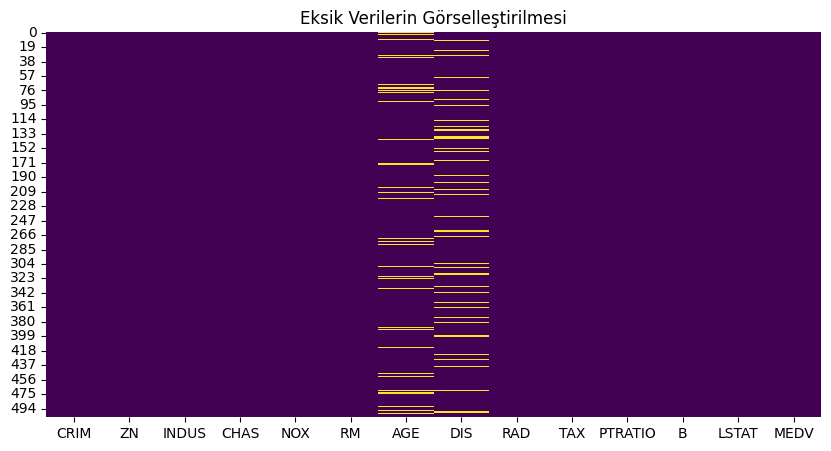

In [ ]:
#eksik değerlerin görselleştirilmesi
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False,cmap="viridis")
plt.title("Eksik Verilerin Görselleştirilmesi")

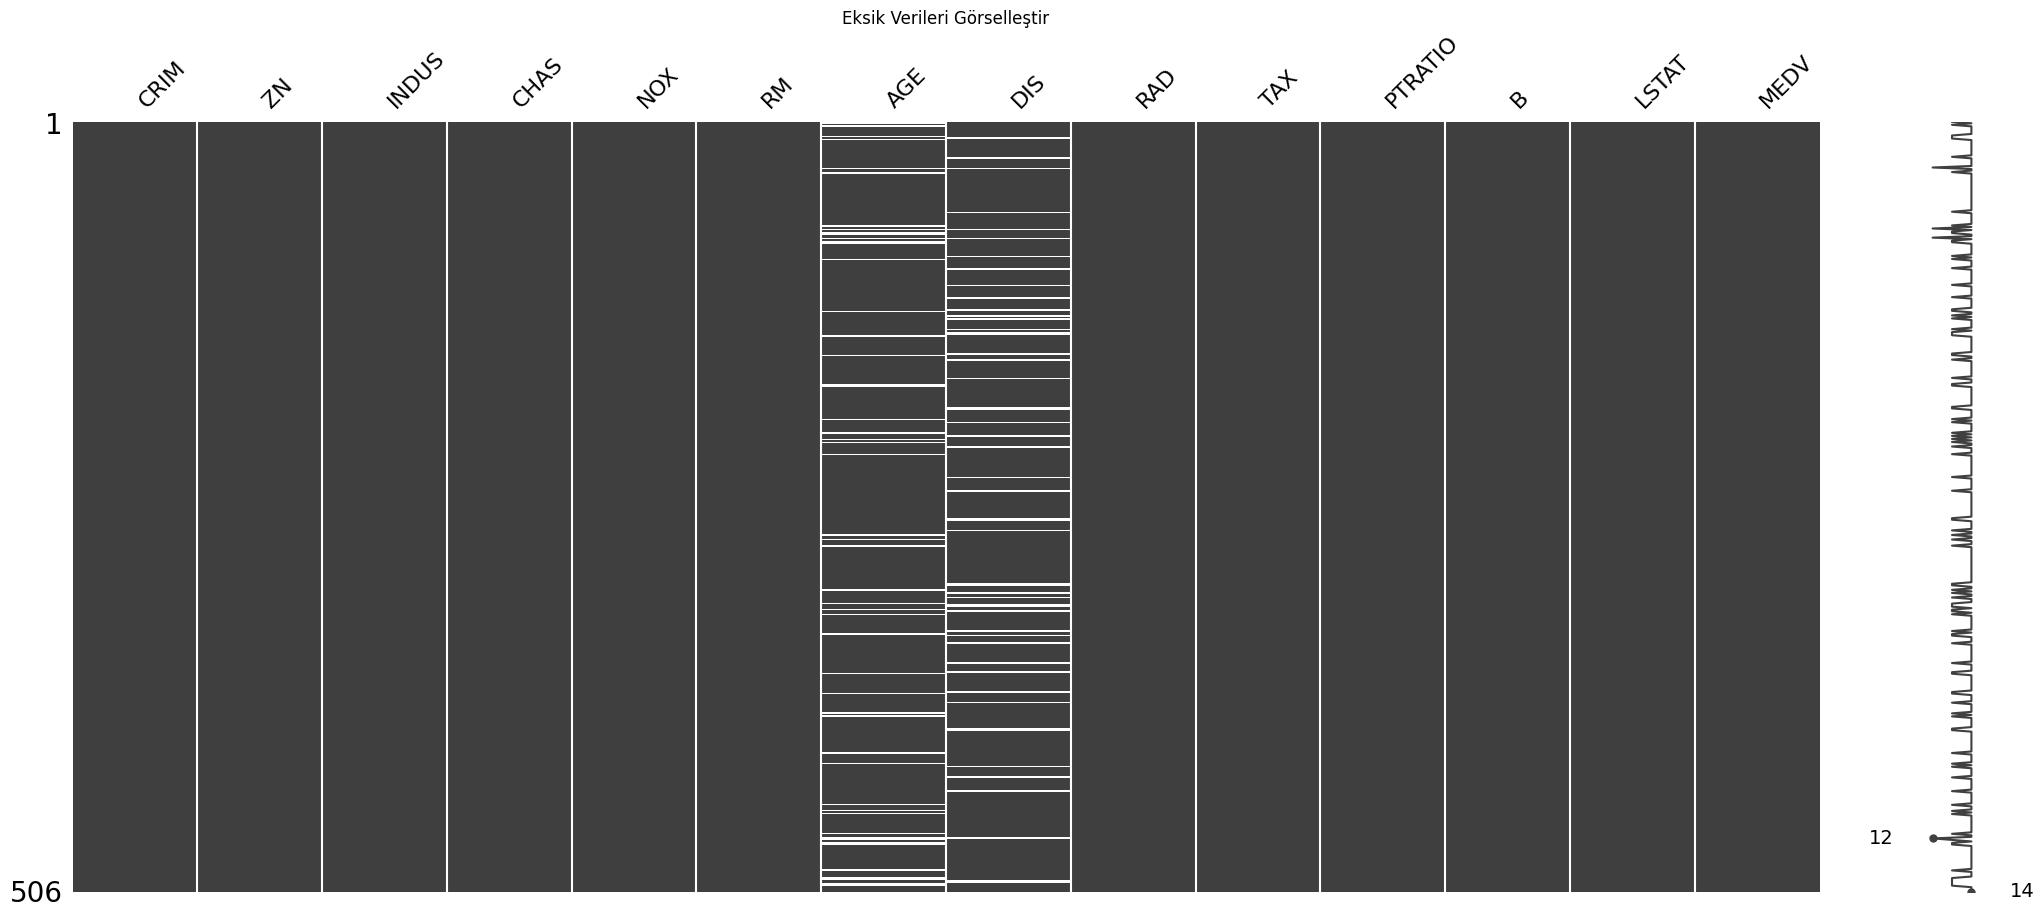

In [ ]:
# alternatif olarak missingno kullanabiliriz
msno.matrix(df)
plt.title("Eksik Verileri Görselleştir")
plt.show()

In [ ]:
#eksiklik oranı analiz tablosu
missing_report = pd.DataFrame({
    "eksik_sayı": df.isnull().sum(),
    "eksik_oran": round(df.isnull().mean() * 100)
})
print(missing_report.sort_values(by="eksik_oran",ascending=False))

         eksik_sayı  eksik_oran
DIS              51        10.0
AGE              51        10.0
INDUS             0         0.0
CHAS              0         0.0
CRIM              0         0.0
ZN                0         0.0
RM                0         0.0
NOX               0         0.0
RAD               0         0.0
TAX               0         0.0
PTRATIO           0         0.0
B                 0         0.0
LSTAT             0         0.0
MEDV              0         0.0


Bu aşamaya kadar:
* veri setindeki eksik değerleri bulduk
* oranları hesapladık
* görsel olarak analiz ettik
* eksiklik türlerinin kavramsal olarak yorumladık (tamamen rastgele çıktı)

## Eksik Veri Doldurma
* Ortalama
* Medyan
* Mod

In [11]:
#housing.csv dosyasını oku
df = pd.read_csv("housing.csv")
#eksik veri simulasyonu
np.random.seed(42)
for col in ["AGE","DIS"]:
  df.loc[df.sample(frac=0.1).index, col] = np.nan

print(df.head())
print(df.isnull().sum())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31     0  0.538  6.575   NaN  4.0900    1  296.0   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07     0  0.469  7.185   NaN  4.9671    2  242.0   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  
CRIM        0
ZN          0
INDUS       0
CHAS        0
NOX         0
RM          0
AGE        51
DIS        51
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT       0
MEDV        0
dtype: int64


In [12]:
# ortalama ile yani mean ile eksik veriyi doldurma
df_mean = df.copy()
mean_value = df_mean["AGE"].mean()
df_mean["AGE"].fillna(mean_value, inplace = True)

print(f"Age sütunu ortalama {mean_value:2f} değeri ile dolduruldu")
print(f"{df_mean["AGE"].isnull().sum()} eksik değer kaldı")

Age sütunu ortalama 68.252747 değeri ile dolduruldu
0 eksik değer kaldı


/tmp/ipykernel_17953/1931253171.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mean["AGE"].fillna(mean_value, inplace = True)


In [13]:
# ortalama ile yani mean ile eksik veriyi doldurma
df_median = df.copy()
median_value = df_median["DIS"].median()
df_median["DIS"].fillna(median_value, inplace = True)

print(f"DIS sütunu median {median_value:2f} değeri ile dolduruldu")
print(f"{df_median["DIS"].isnull().sum()} eksik değer kaldı")

DIS sütunu median 3.215700 değeri ile dolduruldu
0 eksik değer kaldı


/tmp/ipykernel_17953/82853712.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_median["DIS"].fillna(median_value, inplace = True)


In [14]:
# Mod ile doldurma
np.random.seed(42)
for col in ["CHAS"]:
  df.loc[df.sample(frac=0.1).index,col] = np.nan

df_mode = df.copy()
mode_value = df_mode["CHAS"].mode()[0]
df_mode["CHAS"].fillna(mode_value, inplace=True)

print(f"CHAS sütunu mod {mode_value} değeri ile dolduruldu")
print(f"{df_mode["CHAS"].isnull().sum()} eksik değer kaldı")

CHAS sütunu mod 0.0 değeri ile dolduruldu
0 eksik değer kaldı


/tmp/ipykernel_17953/4237318027.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_mode["CHAS"].fillna(mode_value, inplace=True)


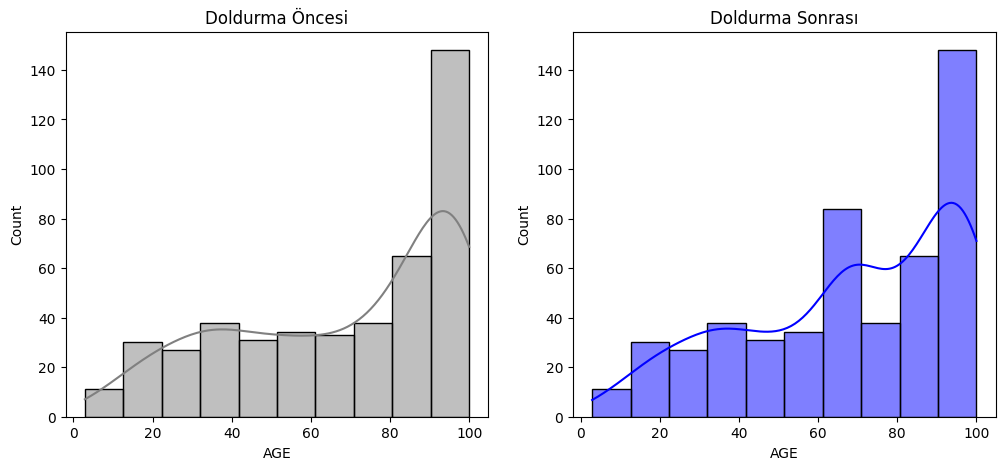

In [16]:
#doldurma öncesi ve sonrası karşılaştırma
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df["AGE"],color="gray",kde=True)
plt.title("Doldurma Öncesi")
plt.subplot(1,2,2)
sns.histplot(df_mean["AGE"],color="blue",kde=True)
plt.title("Doldurma Sonrası")
plt.show()

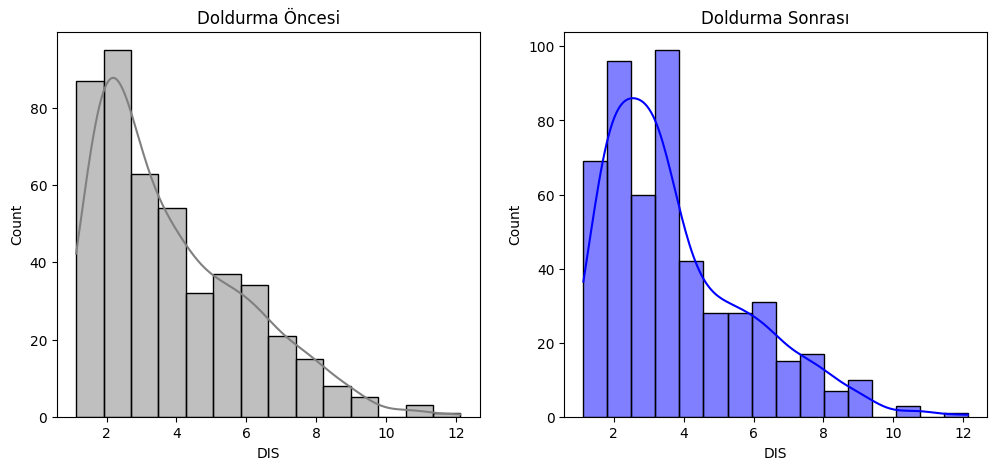

In [18]:
#doldurma öncesi ve sonrası karşılaştırma
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df["DIS"],color="gray",kde=True)
plt.title("Doldurma Öncesi")
plt.subplot(1,2,2)
sns.histplot(df_median["DIS"],color="blue",kde=True)
plt.title("Doldurma Sonrası")
plt.show()

Bu aşamaya kadar
* Ortalama ile doldurma
* Medyan doldurma
* Mod ile doldurma

## Gelişmiş Yöntemler
* KNN ile eksik veri doldurma
* Regresyon ile eksik veri doldurma


In [22]:
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [19]:
#veriyi yükle
df = pd.read_csv("housing.csv")
np.random.seed(42)
for col in ["AGE","DIS","RM"]:
  df.loc[df.sample(frac=0.1).index, col] = np.nan

print(df.isnull().sum())

CRIM        0
ZN          0
INDUS       0
CHAS        0
NOX         0
RM         51
AGE        51
DIS        51
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT       0
MEDV        0
dtype: int64


In [23]:
#KNN ile doldurma
df_knn = df.copy()

imputer = KNNImputer(n_neighbors=3)
df_knn_imputed = imputer.fit_transform(df_knn)

#dönüşüm sonrası np array den pandas df e çevir

df_knn = pd.DataFrame(df_knn_imputed, columns=df.columns)

df_knn.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [26]:
#regresyon ile kayıp değer giderme
df_reg = df.copy()

#eksik olmayan satırları train, eksik olanları ise predict olarak ayır
train_data = df_reg[df_reg["AGE"].notnull()] #eksik olmayanlar
predict_data = df_reg[df_reg["AGE"].isnull()] #eksik olanlar

train_data = train_data.fillna(train_data.mean())
predict_data = predict_data.fillna(predict_data.mean())
#bağımlı ve bağımsız değişkenleri ayır

X_train = train_data.drop(columns = ["AGE"])
y_train = train_data["AGE"]
X_pred = predict_data.drop(columns = ["AGE"])

#regresyon modeli oluştur
model = LinearRegression()
model.fit(X_train,y_train)

# eksik age değerlerini tahmin et
predicted_values = model.predict(X_pred)

#tahmin edilen değerleri yerine yaz
df_reg.loc[df_reg["AGE"].isnull(),"AGE"] = predicted_values

df_reg["AGE"].isnull().sum()

np.int64(0)